# Q. Analytical Derivation

# Q1


## 1. Prediction Distribution

Given

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}
$$

with

$$
x_{k-1}^+ \sim N(m_{k-1},P_{k-1}),\qquad
w_{k-1}\sim N(0,\Sigma_p).
$$

Since a linear transformation of Gaussian variables is Gaussian,

$$
x_k^- \sim N(m_k^-,P_k^-).
$$

### Mean

$$
m_k^- = E[x_k^-]
$$

$$
=E[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}]
$$

$$
=A_{k-1}m_{k-1}.
$$

### Covariance

$$
P_k^-=\mathrm{Var}(x_k^-)
$$

$$
=A_{k-1}P_{k-1}A_{k-1}^T+G_{k-1}\Sigma_pG_{k-1}^T.
$$

---

## 2. Distribution of the Measurement

Measurement model:

$$
y_k^- = H_kx_k^-+z_k,
$$

where

$$
z_k\sim N(0,\Sigma_m).
$$

Hence

$$
y_k^- \sim N(H_km_k^-,\,H_kP_k^-H_k^T+\Sigma_m).
$$

since

$$
E[y_k^-]=H_km_k^-,
$$

and

$$
\mathrm{Var}(y_k^-)=H_kP_k^-H_k^T+\Sigma_m.
$$

---

## 3. Joint Distribution

Therefore,

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
N
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right).
$$

The cross covariance is

$$
\mathrm{Cov}(x_k^-,y_k^-)=P_k^-H_k^T.
$$

---

## 4. Posterior Distribution

Conditioning on the observation

$$
y_k^-=y_k^{obs},
$$

gives

$$
x_k^+=(x_k^-|y_k^-=y_k^{obs})
\sim N(m_k,P_k).
$$

The Kalman gain is

$$
K_k=P_k^-H_k^T(H_kP_k^-H_k^T+\Sigma_m)^{-1}.
$$

Updated mean:

$$
m_k=m_k^-+K_k(y_k^{obs}-H_km_k^-).
$$

Updated covariance:

$$
P_k=(I-K_kH_k)P_k^-.
$$

---

## 5. Conditional Mean and Covariance

Therefore,

$$
E[x_k^-|y_k^-=y_k^{obs}]
=
m_k
=
m_k^-+K_k(y_k^{obs}-H_km_k^-).
$$

and

$$
\mathrm{Var}(x_k^-|y_k^-=y_k^{obs}]
=
P_k
=
(I-K_kH_k)P_k^-.
$$


# Q. 1-D Example



Prediction:
$$m_k^-=am_{k-1},\qquad P_k^-=a^2P_{k-1}+q.$$

Innovation:
$$v_k=y_k^{obs}-hm_k^-,$$

$$S_k=h^2P_k^-+r.$$

Kalman gain:
$$K_k=\frac{P_k^-h}{S_k}.$$

Update:
$$m_k=m_k^-+K_kv_k,$$

$$P_k=(1-K_kh)P_k^-=\left(1-\frac{P_k^-h^2}{S_k}\right)P_k^-.$$

Predictive measurement:
$$p(y_k^-|Y_{k-1})=N(hm_k^-,h^2P_k^-+r).$$

Posterior predictive:
$$p(y_k^-|Y_k)=N(hm_k,h^2P_k+r).$$


# Q. 2D-Position Estimation

# Q. 2D Position Estimation – Part A

The hidden state vector is

$$
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where

- \(p_x(k), p_y(k)\) are the position components,
- \(v_x(k), v_y(k)\) are the velocity components.

The measurement vector is

$$
y_k=
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The state evolution is

$$
x_k^- = Ax_{k-1}^+ + Gw_{k-1},
$$

and the measurement equation is

$$
y_k^- = Hx_k^- + z_k.
$$

---

# Step 1: Derive the State Transition Matrix \(A\)

For a constant-velocity model,

$$
p_x(k)=p_x(k-1)+\Delta t\,v_x(k-1),
$$

$$
p_y(k)=p_y(k-1)+\Delta t\,v_y(k-1).
$$

Since the velocity is assumed constant between consecutive time steps,

$$
v_x(k)=v_x(k-1),
$$

$$
v_y(k)=v_y(k-1).
$$

Writing these four equations together gives

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
}
$$

---

# Step 2: Derive the Measurement Matrix \(H\)

The measurements contain only the position components,

$$
y_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)
\end{bmatrix}.
$$

Since velocity is not measured,

$$
p_x(k)=
\begin{bmatrix}
1&0&0&0
\end{bmatrix}
x_k,
$$

and

$$
p_y(k)=
\begin{bmatrix}
0&1&0&0
\end{bmatrix}
x_k.
$$

Combining both equations,

$$
y_k=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
x_k.
$$

Hence,

$$
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
}
$$

---

# Step 3: Derive the Process Noise Matrix \(G\)

Assume the process noise represents an unknown acceleration

$$
w_k=
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

Using the kinematic equations,

the position update due to acceleration is

$$
\Delta p=\frac12a(\Delta t)^2,
$$

while the velocity update is

$$
\Delta v=a\Delta t.
$$

Applying these equations independently to the \(x\)- and \(y\)-directions gives

$$
\begin{aligned}
p_x(k)&=p_x(k-1)+v_x(k-1)\Delta t+\frac12a_x(\Delta t)^2,\\
p_y(k)&=p_y(k-1)+v_y(k-1)\Delta t+\frac12a_y(\Delta t)^2,\\
v_x(k)&=v_x(k-1)+a_x\Delta t,\\
v_y(k)&=v_y(k-1)+a_y\Delta t.
\end{aligned}
$$

Collecting the acceleration terms,

$$
Gw_k=
\begin{bmatrix}
\frac12(\Delta t)^2&0\\
0&\frac12(\Delta t)^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
}
$$

---

# Final Result

The matrices for the two-dimensional constant-velocity Kalman filter are

$$
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
}
$$

$$
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
}
$$

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
}
$$

These matrices define the state transition, measurement, and process noise models for the two-dimensional constant-velocity Kalman filter.

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### PART B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

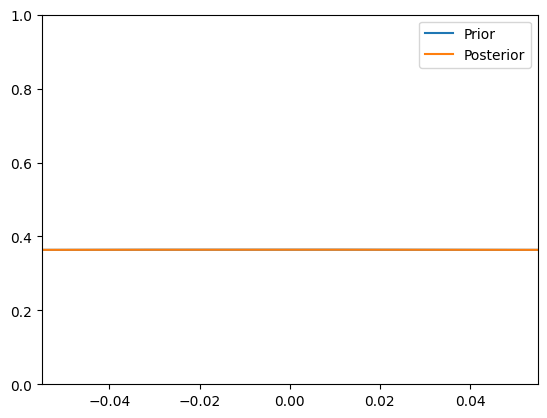

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
a,q,h,r=1.0,0.2,1.0,0.5
m,P=0.,1.
yobs=2.
x=np.linspace(-4,4,400)
fig,ax=plt.subplots()
def pdf(x,m,v): return 1/np.sqrt(2*np.pi*v)*np.exp(-(x-m)**2/(2*v))
prior,=ax.plot([],[],label='Prior')
post,=ax.plot([],[],label='Posterior')
ax.legend(); ax.set_ylim(0,1)
mp=a*m; Pp=a*a*P+q; S=h*h*Pp+r; K=Pp*h/S; m2=mp+K*(yobs-h*mp); P2=(1-K*h)*Pp
def upd(i):
 t=i/30
 prior.set_data(x,pdf(x,mp,Pp))
 post.set_data(x,pdf(x,(1-t)*mp+t*m2,(1-t)*Pp+t*P2))
 return prior,post
ani=FuncAnimation(fig,upd,frames=31,interval=100,blit=True)
plt.show()

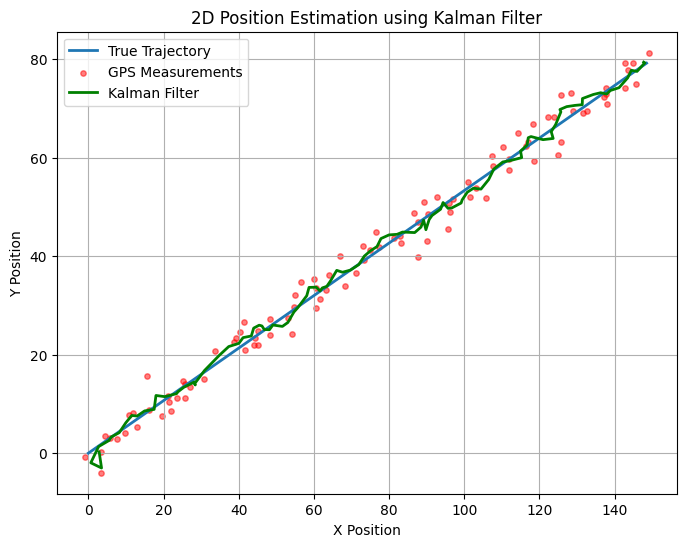

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Generate Sample GPS Data
# ===============================

np.random.seed(10)

dt = 1.0
N = 100

# True trajectory (constant velocity)
true_x = np.zeros((4, N))

true_x[:,0] = [0, 0, 1.5, 0.8]

for k in range(1, N):
    true_x[0,k] = true_x[0,k-1] + dt*true_x[2,k-1]
    true_x[1,k] = true_x[1,k-1] + dt*true_x[3,k-1]
    true_x[2,k] = true_x[2,k-1]
    true_x[3,k] = true_x[3,k-1]

# Noisy GPS measurements
gps_std = 2.5

measurements = np.zeros((2,N))
measurements[0] = true_x[0] + np.random.normal(0,gps_std,N)
measurements[1] = true_x[1] + np.random.normal(0,gps_std,N)

# ===============================
# Kalman Filter Matrices
# ===============================

A = np.array([
    [1,0,dt,0],
    [0,1,0,dt],
    [0,0,1,0],
    [0,0,0,1]
])

H = np.array([
    [1,0,0,0],
    [0,1,0,0]
])

G = np.array([
    [0.5*dt**2,0],
    [0,0.5*dt**2],
    [dt,0],
    [0,dt]
])

# Process noise
sigma_acc = 0.2
Q = sigma_acc**2 * np.eye(2)

# Measurement noise
R = gps_std**2 * np.eye(2)

# ===============================
# Initial Conditions
# ===============================

x = np.array([0,0,0,0],dtype=float)

P = np.eye(4)*20

filtered = np.zeros((4,N))

# ===============================
# Kalman Filter
# ===============================

for k in range(N):

    # Prediction
    x_pred = A @ x

    P_pred = A @ P @ A.T + G @ Q @ G.T

    # Measurement
    y = measurements[:,k]

    # Innovation
    v = y - H @ x_pred

    # Innovation covariance
    S = H @ P_pred @ H.T + R

    # Kalman gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update
    x = x_pred + K @ v

    P = (np.eye(4) - K @ H) @ P_pred

    filtered[:,k] = x

# ===============================
# Plot Results
# ===============================

plt.figure(figsize=(8,6))

plt.plot(true_x[0],true_x[1],
         label='True Trajectory',
         linewidth=2)

plt.scatter(measurements[0],
            measurements[1],
            color='red',
            s=15,
            alpha=0.5,
            label='GPS Measurements')

plt.plot(filtered[0],
         filtered[1],
         color='green',
         linewidth=2,
         label='Kalman Filter')

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("2D Position Estimation using Kalman Filter")

plt.grid(True)
plt.legend()

plt.show()